# Phase 6 : Preprocessing

**Objective**

Prepare the validated dataset for unsupervised machine learning (PCA and K-Means clustering) by applying preprocessing techniques that ensure features contribute fairly to distance-based algorithms.

**Inputs**

* validated_dataset.csv<br>
* Original questionnaire features<br>
* Engineered features approved in Notebook 05

**Outputs**

* preprocessed_dataset.csv<br>
* scaled_df<br>
* Preprocessing report

**Expected Deliverables**

By the end of this notebook we will have:

* Selected the final feature set for modeling.<br>
* Distinguished between features used for clustering and those kept only for interpretation.<br>
* Applied feature scaling where appropriate.<br>
* Verified that preprocessing has not introduced errors.<br>
* Exported a clean dataset ready for PCA.

In [13]:
import pandas as pd

validation_df = pd.read_csv("dataset\\engineered_dataset.csv")

# 1) Feature Inventory

Exactly which columns will enter the machine learning pipeline, and why?<br>
Before preprocessing, identify exactly which features should enter the machine <br>learning pipeline and classify every column in the dataset according to its purpose.

Here we are following a hybrid approach where we will be selecting engineered features along with those features that were not included in the engineered features which will help in reducing redundancy.

In [15]:
engineered_features = [

    "MENTAL_WELLNESS_INDEX",
    "SOCIAL_WELLNESS_INDEX",
    "PHYSICAL_WELLNESS_INDEX",
    "PRODUCTIVITY_INDEX",
    "RECOVERY_WELLBEING_INDEX",
    "STRESS_BURDEN_INDEX"

]

original_features = [

    "PLACES_VISITED",
    "DONATION",
    "BMI_RANGE",
    "SUFFICIENT_INCOME",
    "PERSONAL_AWARDS",
    "AGE"

]

In [14]:
validation_df.shape

(15489, 52)

**Create the Modeling Dataset**

In [18]:
# Create Modeling Dataset

model_features = original_features + engineered_features

model_df = validation_df[model_features].copy()

print("Model Dataset Shape:", model_df.shape)

display(model_df.head())

Model Dataset Shape: (15489, 12)


,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
0,2,0,1,1,4,2,0.333333,0.333333,0.570370,0.40,0.375,0.466667
1,4,2,2,2,3,2,0.366667,0.700000,0.540741,0.50,0.600,0.400000
2,3,2,2,2,4,2,0.366667,0.600000,0.503704,0.25,0.475,0.500000
3,10,5,2,1,5,3,0.300000,0.666667,0.496296,0.25,0.250,0.700000
4,3,4,2,2,8,3,0.266667,0.566667,0.703704,0.35,0.650,0.233333


**Feature Categories**

In [19]:
feature_inventory = pd.DataFrame({

    "Feature": model_features,

    "Category": [

        "Original",
        "Original",
        "Original",
        "Original",
        "Original",
        "Original",

        "Engineered",
        "Engineered",
        "Engineered",
        "Engineered",
        "Engineered",
        "Engineered"

    ]

})

display(feature_inventory)

,Feature,Category
0,PLACES_VISITED,Original
1,DONATION,Original
2,BMI_RANGE,Original
3,SUFFICIENT_INCOME,Original
4,PERSONAL_AWARDS,Original
5,AGE,Original
6,MENTAL_WELLNESS_INDEX,Engineered
7,SOCIAL_WELLNESS_INDEX,Engineered
8,PHYSICAL_WELLNESS_INDEX,Engineered
9,PRODUCTIVITY_INDEX,Engineered


# Standard Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_array = scaler.fit_transform(model_df)

scaled_df = pd.DataFrame(
    scaled_array,
    columns=model_df.columns,
    index=model_df.index
)

print("Scaling completed successfully.")

scaled_df.head()

Scaling completed successfully.


,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
0,-0.973015,-1.467140,-0.831894,-1.646460,-0.553249,0.415538,-0.239109,-1.122771,-0.134217,-0.402543,-1.255317,0.296568
1,-0.369800,-0.386846,1.202077,0.607364,-0.876764,0.415538,-0.062975,0.497604,-0.308836,0.057570,0.039073,-0.049436
2,-0.671408,-0.386846,1.202077,0.607364,-0.553249,0.415538,-0.062975,0.055683,-0.527111,-1.092712,-0.680033,0.469570
3,1.439846,1.233596,1.202077,-1.646460,-0.229734,1.474310,-0.415242,0.350297,-0.570765,-1.092712,-1.974423,1.507582
4,-0.671408,0.693449,1.202077,0.607364,0.740812,1.474310,-0.591375,-0.091623,0.651570,-0.632600,0.326715,-0.914445


<h4>Scaling Validation</h4>

In [22]:

scaling_summary = pd.DataFrame({

    "Mean": scaled_df.mean(),

    "Standard Deviation": scaled_df.std()

})

display(
    scaling_summary.round(3)
)

,Mean,Standard Deviation
PLACES_VISITED,-0.0,1.0
DONATION,0.0,1.0
BMI_RANGE,-0.0,1.0
SUFFICIENT_INCOME,0.0,1.0
PERSONAL_AWARDS,0.0,1.0
AGE,0.0,1.0
MENTAL_WELLNESS_INDEX,-0.0,1.0
SOCIAL_WELLNESS_INDEX,0.0,1.0
PHYSICAL_WELLNESS_INDEX,-0.0,1.0
PRODUCTIVITY_INDEX,0.0,1.0


Note: Because pandas uses the sample standard deviation (ddof=1) by default, we can see values like 1.00003 or 0.99997. Because of that we get -0 That's perfectly normal.

<h4>Visual Validation</h4>

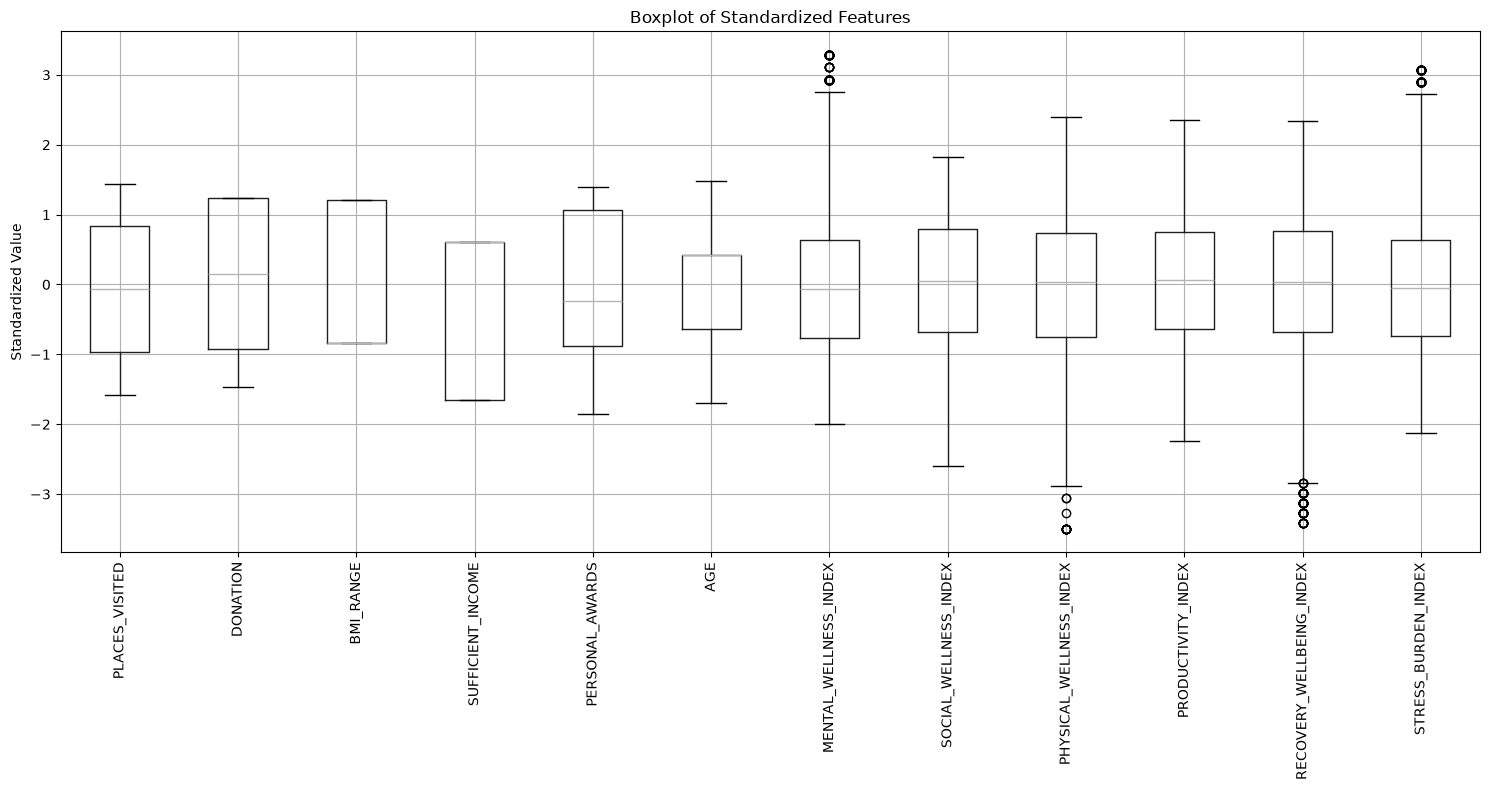

In [24]:
import matplotlib.pyplot as plt

scaled_df.boxplot(
    figsize=(15,8),
    rot=90
)

plt.title("Boxplot of Standardized Features")

plt.ylabel("Standardized Value")

plt.tight_layout()

plt.show()

This image fulfills our observation goal as all the boxplots should be centered around 0 and no one should appear very far from it. <br>And we are expecting this because the mathematical formula for standard deviation forces the mean of data to become zero.

In [26]:
scaled_df.to_csv(
    "dataset//preprocessed_dataset.csv",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.
